<a href="https://colab.research.google.com/github/asmaamuhamed20/Toxic-Content-Classification/blob/main/NLP_Toxic_Detection_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Cellula_1week_Asmaa/cellula_toxic_data.csv")

print(df.head())
print(df.columns)


                                               query  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   

                           image descriptions  Toxic Category  
0          A child playing in a sunny meadow.            Safe  
1     A family enjoying a picnic in the park.            Safe  
2          A child playing in a sunny meadow.            Safe  
3  Police tape across a crime scene at night.  Violent Crimes  
4          A child playing in a sunny meadow.       Elections  
Index(['query', 'image descriptions', 'Toxic Category'], dtype='object')


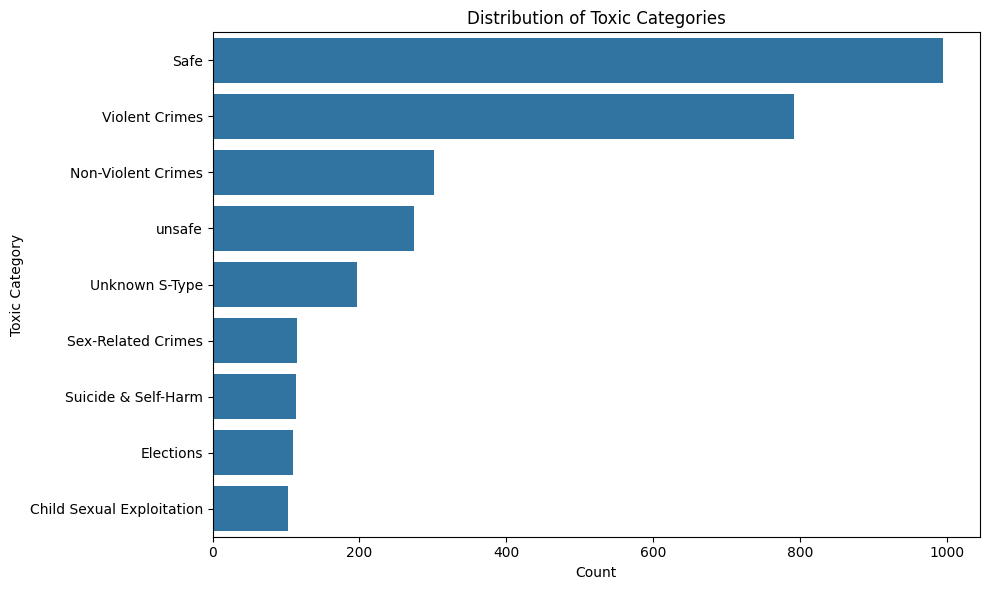

Category distribution:
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
category_counts = df['Toxic Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Distribution of Toxic Categories')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('category_distribution.png')
plt.show()

print("Category distribution:")
print(category_counts)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, SpatialDropout1D, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from matplotlib.backends.backend_pdf import PdfPages
import tensorflow as tf

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Cellula_1week_Asmaa/cellula_toxic_data.csv")

In [6]:
print("Category distribution:")
category_counts = df['Toxic Category'].value_counts()
print(category_counts)

Category distribution:
Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64


In [7]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Toxic Category'])
num_classes = len(label_encoder.classes_)

print("\nClasses:", label_encoder.classes_)
print("Number of classes:", num_classes)


Classes: ['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']
Number of classes: 9


In [8]:
max_words = 5000
max_len = 35

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>",
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(df['query'].values)

X = tokenizer.texts_to_sequences(df['query'].values)
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

print("\nVocabulary size:", len(tokenizer.word_index))
print("Data shape:", X.shape)


Vocabulary size: 4534
Data shape: (3000, 35)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [11]:
y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

In [12]:
# solution for immbalance data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weights_dict)


Class weights: {0: np.float64(3.2323232323232323), 1: np.float64(3.0476190476190474), 2: np.float64(1.1053540587219344), 3: np.float64(0.3349031920460492), 4: np.float64(2.8828828828828827), 5: np.float64(2.922374429223744), 6: np.float64(1.7066666666666668), 7: np.float64(0.42077580539119), 8: np.float64(1.2190476190476192)}


In [ ]:
from tensorflow.keras.metrics import Metric

class F1Score(Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_labels = tf.argmax(y_true, axis=1)

        self.precision.update_state(y_true_labels, y_pred_labels)
        self.recall.update_state(y_true_labels, y_pred_labels)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

In [ ]:
def create_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        SpatialDropout1D(0.4),

        Bidirectional(LSTM(64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True)),
        Dropout(0.5),

        Bidirectional(LSTM(32, dropout=0.4, recurrent_dropout=0.4)),
        Dropout(0.5),

        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    optimizer = Adam(learning_rate=0.0005)


    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.build(input_shape=(None, max_len))

    return model

model = create_model()
print("\nModel summary:")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,777 (2.99 MB)

 Trainable params: 784,777 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_f1.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train_categorical,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val_categorical),
    class_weight=class_weights_dict,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.1472 - loss: 2.1722
Epoch 1: val_accuracy improved from -inf to 0.08333, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 373ms/step - accuracy: 0.1471 - loss: 2.1725 - val_accuracy: 0.0833 - val_loss: 2.1830 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.1246 - loss: 2.2880
Epoch 2: val_accuracy improved from 0.08333 to 0.29792, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 353ms/step - accuracy: 0.1250 - loss: 2.2852 - val_accuracy: 0.2979 - val_loss: 1.8838 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.2524 - loss: 1.8696
Epoch 3: val_accuracy improved from 0.29792 to 0.33542, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.2523 - loss: 1.8694 - val_accuracy: 0.3354 - val_loss: 1.6903 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.2406 - loss: 1.7007
Epoch 4: val_accuracy did not improve from 0.33542
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 368ms/step - accuracy: 0.2405 - loss: 1.7011 - val_accuracy: 0.3042 - val_loss: 1.5539 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.2503 - loss: 1.6283
Epoch 5: val_accuracy improved from 0.33542 to 0.48750, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 358ms/step - accuracy: 0.2504 - loss: 1.6279 - val_accuracy: 0.4875 - val_loss: 1.4641 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.3007 - loss: 1.4776
Epoch 6: val_accuracy did not improve from 0.48750
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 342ms/step - accuracy: 0.3007 - loss: 1.4770 - val_accuracy: 0.4833 - val_loss: 1.3277 - learning_rate: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.3664 - loss: 1.2523
Epoch 7: val_accuracy did not improve from 0.48750
60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 354ms/step - accuracy: 0.3664 - loss: 1.2529 - val_accuracy: 0.4354 - val_loss: 1.2951 - learning_rate: 0.0010
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4041 - loss: 1.2330
Epoch 8: val_accuracy improved from 0.48750 to 0.53542, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 370ms/step - accuracy: 0.4039 - loss: 1.2324 - val_accuracy: 0.5354 - val_loss: 1.1866 - learning_rate: 0.0010
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.4389 - loss: 1.0702
Epoch 9: val_accuracy did not improve from 0.53542
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 336ms/step - accuracy: 0.4390 - loss: 1.0702 - val_accuracy: 0.5333 - val_loss: 1.1478 - learning_rate: 0.0010
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5025 - loss: 0.9748
Epoch 10: val_accuracy did not improve from 0.53542
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 361ms/step - accuracy: 0.5027 - loss: 0.9745 - val_accuracy: 0.5292 - val_loss: 1.1232 - learning_rate: 0.0010
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5221 - loss: 0.9611
Epoch 11: val_accuracy did not improve from 0.53542

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 335ms/step - accuracy: 0.5222 - loss: 0.9600 - 

60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 358ms/step - accuracy: 0.6299 - loss: 0.7010 - val_accuracy: 0.5729 - val_loss: 1.0518 - learning_rate: 5.0000e-04
Epoch 15/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6588 - loss: 0.6674
Epoch 15: val_accuracy did not improve from 0.57292
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 334ms/step - accuracy: 0.6587 - loss: 0.6676 - val_accuracy: 0.5354 - val_loss: 1.1262 - learning_rate: 5.0000e-04
Epoch 16/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6473 - loss: 0.6759
Epoch 16: val_accuracy improved from 0.57292 to 0.58750, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 342ms/step - accuracy: 0.6472 - loss: 0.6755 - val_accuracy: 0.5875 - val_loss: 1.0247 - learning_rate: 5.0000e-04
Epoch 17/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.6442 - loss: 0.6061
Epoch 17: val_accuracy did not improve from 0.58750
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 354ms/step - accuracy: 0.6445 - loss: 0.6060 - val_accuracy: 0.5479 - val_loss: 1.1283 - learning_rate: 5.0000e-04
Epoch 18/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6721 - loss: 0.6316
Epoch 18: val_accuracy did not improve from 0.58750
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.6721 - loss: 0.6315 - val_accuracy: 0.5792 - val_loss: 1.0792 - learning_rate: 5.0000e-04
Epoch 19/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6922 - loss: 0.5642
Epoch 19: val_accuracy improved from 0.58750 to 0.61250, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 353ms/step - accuracy: 0.6921 - loss: 0.5644 - val_accuracy: 0.6125 - val_loss: 1.0685 - learning_rate: 5.0000e-04
Epoch 20/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7081 - loss: 0.5562
Epoch 20: val_accuracy did not improve from 0.61250
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 336ms/step - accuracy: 0.7080 - loss: 0.5559 - val_accuracy: 0.5958 - val_loss: 1.0657 - learning_rate: 5.0000e-04
Epoch 21/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7146 - loss: 0.5281
Epoch 21: val_accuracy improved from 0.61250 to 0.62083, saving model to best_model_f1.h5


60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 376ms/step - accuracy: 0.7147 - loss: 0.5278 - val_accuracy: 0.6208 - val_loss: 1.0495 - learning_rate: 5.0000e-04
Epoch 22/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7421 - loss: 0.4910
Epoch 22: val_accuracy did not improve from 0.62083
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 353ms/step - accuracy: 0.7419 - loss: 0.4911 - val_accuracy: 0.6083 - val_loss: 1.0774 - learning_rate: 5.0000e-04
Epoch 23/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7093 - loss: 0.5785
Epoch 23: val_accuracy did not improve from 0.62083
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.7093 - loss: 0.5777 - val_accuracy: 0.5896 - val_loss: 1.0956 - learning_rate: 5.0000e-04
Epoch 24/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.7589 - loss: 0.4945
Epoch 24: val_accuracy did not improve from 0.62083

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 353ms/step - accuracy: 0.7588 - l

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# F1 score
f1_per_class = f1_score(y_test, y_pred_classes, average=None)
f1_weighted = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro = f1_score(y_test, y_pred_classes, average='macro')

print("=" * 60)
print("F1 SCORE RESULTS")
print("=" * 60)

print("\nF1 Score per class:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name:30}: {f1_per_class[i]:.4f}")

print(f"\n{'Weighted F1 Score':30}: {f1_weighted:.4f}")
print(f"{'Macro F1 Score':30}: {f1_macro:.4f}")

# Accuracy
accuracy = np.mean(y_test == y_pred_classes)
print(f"{'Accuracy':30}: {accuracy:.4f}")

# Classification report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes,
                          target_names=label_encoder.classes_,
                          digits=4))

NameError: name 'y_test' is not defined

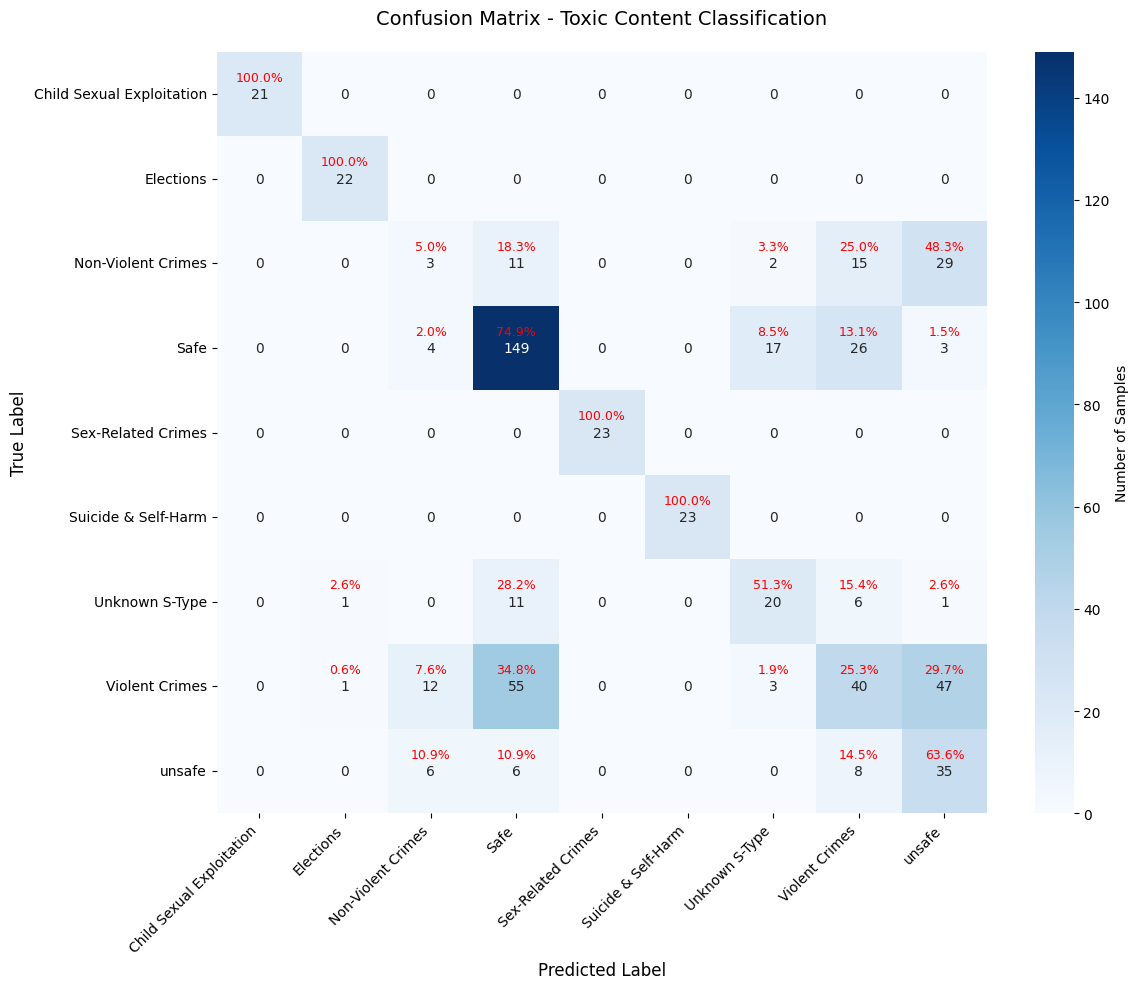

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# confsion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_classes)

# Percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percent = np.nan_to_num(cm_percent)

# HeatMap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Samples'})


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            plt.text(j + 0.5, i + 0.3, f'{cm_percent[i, j]:.1f}%',
                    ha='center', va='center', fontsize=9, color='red')

plt.title('Confusion Matrix - Toxic Content Classification', fontsize=14, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

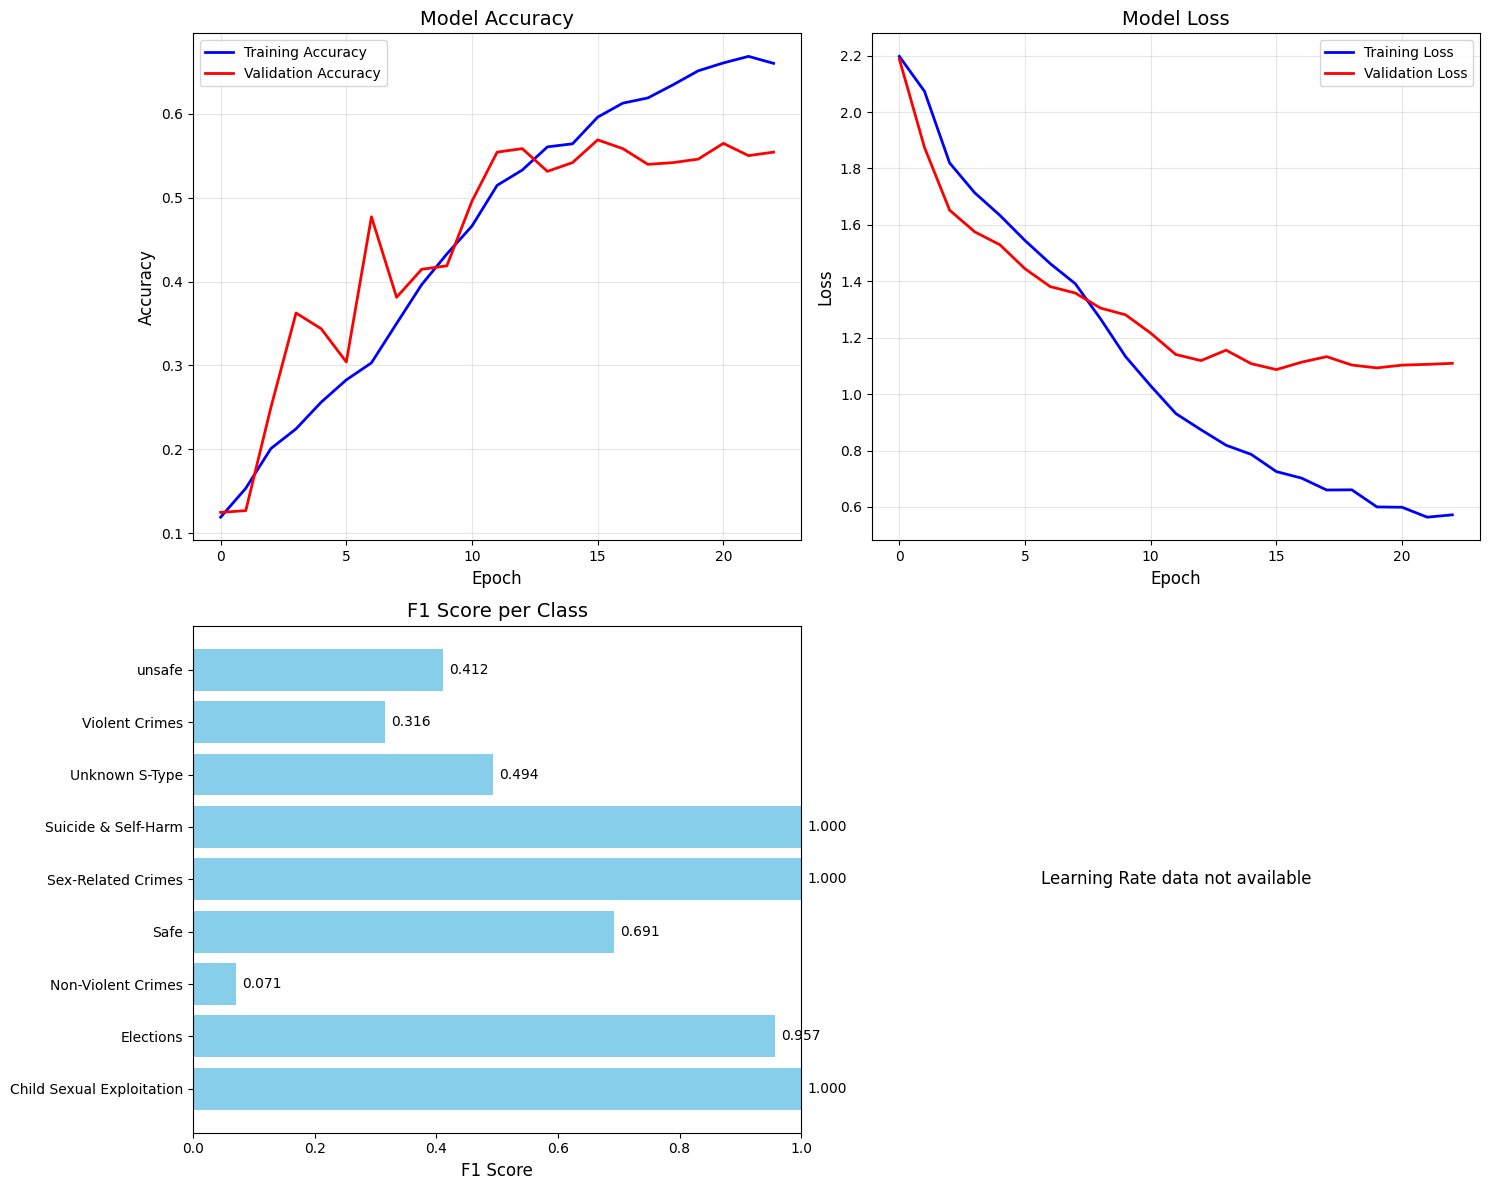

In [ ]:
# Training graphs
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1 Score
ax3.barh(label_encoder.classes_, f1_per_class, color='skyblue')
ax3.set_title('F1 Score per Class', fontsize=14)
ax3.set_xlabel('F1 Score', fontsize=12)
ax3.set_xlim(0, 1)

for i, v in enumerate(f1_per_class):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# Learning Rate
if 'lr' in history.history:
    ax4.plot(history.history['lr'], linewidth=2, color='green')
    ax4.set_title('Learning Rate Schedule', fontsize=14)
    ax4.set_ylabel('Learning Rate', fontsize=12)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
else:
    ax4.axis('off')
    ax4.text(0.5, 0.5, 'Learning Rate data not available',
             ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()